In [1]:
import pandas as pd
import nltk
import json
import random
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model


from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.optimizers import SGD
# Create tkinter GUI
import tkinter 
from tkinter import *

# added for evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split



In [2]:
intents_file = open("intents.json", encoding='utf-8').read()
intents = json.loads(intents_file)

In [3]:
# Validate intents JSON structure

for intent in intents["intents"]:

    if "tag" not in intent:
        print("Error: Missing tag")

    if "patterns" not in intent:
        print("Error: Missing patterns")

    if "responses" not in intent:
        print("Error: Missing responses")

print("Validation completed")

Validation completed


In [4]:
# Check for duplicate intent tags

tags = [intent["tag"] for intent in intents["intents"]]

duplicate_tags = set(
    tag for tag in tags
    if tags.count(tag) > 1
)

print("Duplicate tags:", duplicate_tags)

Duplicate tags: set()


In [5]:
# Check for empty patterns

for intent in intents["intents"]:

    if len(intent["patterns"]) == 0:
        print("Empty patterns:", intent["tag"])

Empty patterns: noanswer
Empty patterns: search_blood_pressure_by_patient_id
Empty patterns: search_pharmacy_by_name
Empty patterns: search_hospital_by_params
Empty patterns: search_hospital_by_type


In [6]:
# Check data types in intents

for intent in intents["intents"]:

    if not isinstance(intent["tag"], str):
        print("Invalid tag type:", intent["tag"])

    if not isinstance(intent["patterns"], list):
        print("Invalid patterns type:", intent["tag"])

    if not isinstance(intent["responses"], list):
        print("Invalid responses type:", intent["tag"])

print("Type validation completed")

Type validation completed


# Exploratory Data Analysis (EDA)


In [3]:

for intent in intents["intents"]:
    print(intent["tag"], "→", len(intent["patterns"]))

greeting → 7
aiolearn → 7
goodbye → 5
thanks → 5
noanswer → 0
options → 5
adverse_drug → 5
blood_pressure → 5
blood_pressure_search → 5
search_blood_pressure_by_patient_id → 0
pharmacy_search → 5
search_pharmacy_by_name → 0
hospital_search → 5
search_hospital_by_params → 0
search_hospital_by_type → 0


# Create DataFrame for intent pattern counts

In [4]:
# Create DataFrame

data = []

for intent in intents["intents"]:
    data.append({
        "tag": intent["tag"],
        "num_patterns": len(intent["patterns"])
    })

data = pd.DataFrame(data)

print(data)

                                    tag  num_patterns
0                              greeting             7
1                              aiolearn             7
2                               goodbye             5
3                                thanks             5
4                              noanswer             0
5                               options             5
6                          adverse_drug             5
7                        blood_pressure             5
8                 blood_pressure_search             5
9   search_blood_pressure_by_patient_id             0
10                      pharmacy_search             5
11              search_pharmacy_by_name             0
12                      hospital_search             5
13            search_hospital_by_params             0
14              search_hospital_by_type             0


In [5]:
data["num_patterns"].describe()

count    15.000000
mean      3.600000
std       2.720294
min       0.000000
25%       0.000000
50%       5.000000
75%       5.000000
max       7.000000
Name: num_patterns, dtype: float64

In [6]:
data["num_patterns"].mean()

np.float64(3.6)

In [7]:
data[data["num_patterns"] > 0]["num_patterns"].mean()

np.float64(5.4)

C:\Users\HP\AppData\Local\Temp\ipykernel_16620\3017680488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


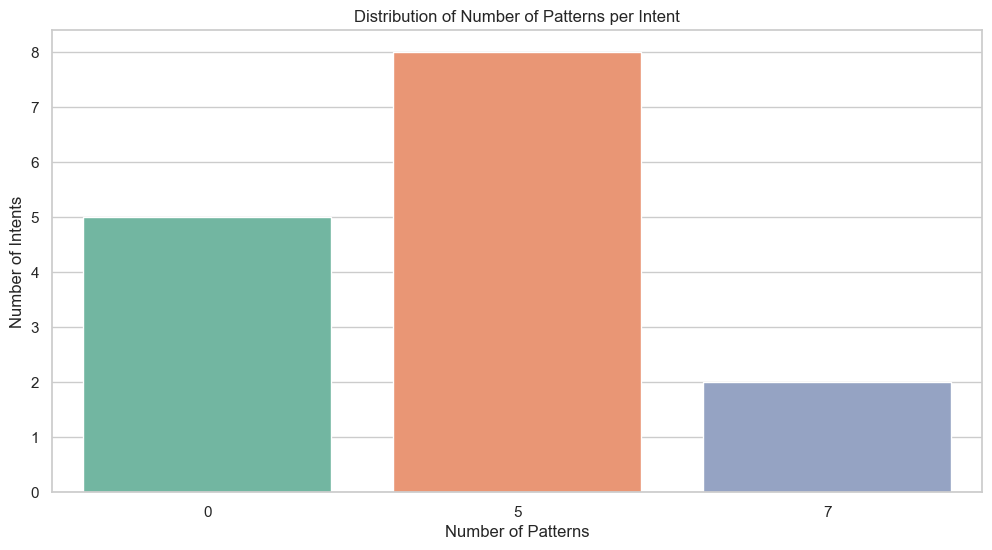

In [8]:
# Countplot of the number of patterns per intent

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6)),

sns.countplot(
    data=data,
    x="num_patterns",palette='Set2'
)

plt.title("Distribution of Number of Patterns per Intent")
plt.xlabel("Number of Patterns")
plt.ylabel("Number of Intents")

plt.show()

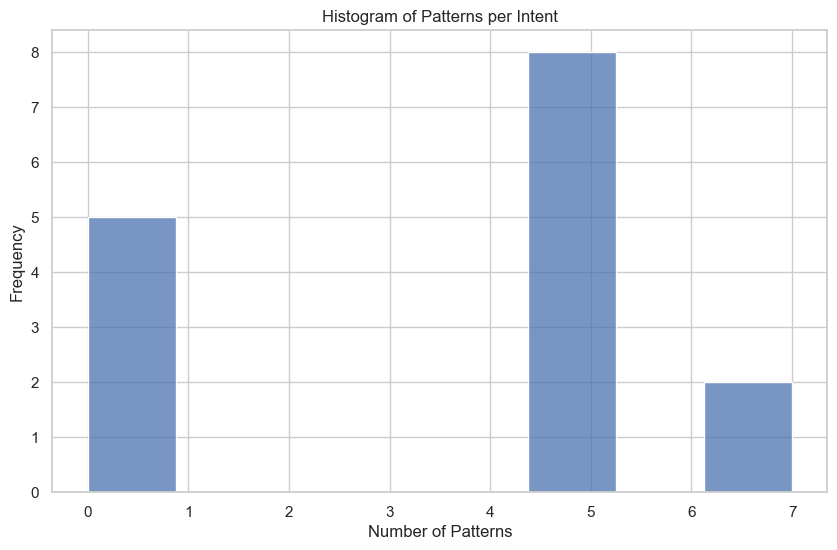

In [9]:
# Histogram of the number of patterns per intent
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="num_patterns",
    bins=8
)

plt.title("Histogram of Patterns per Intent")
plt.xlabel("Number of Patterns")
plt.ylabel("Frequency")

plt.show()

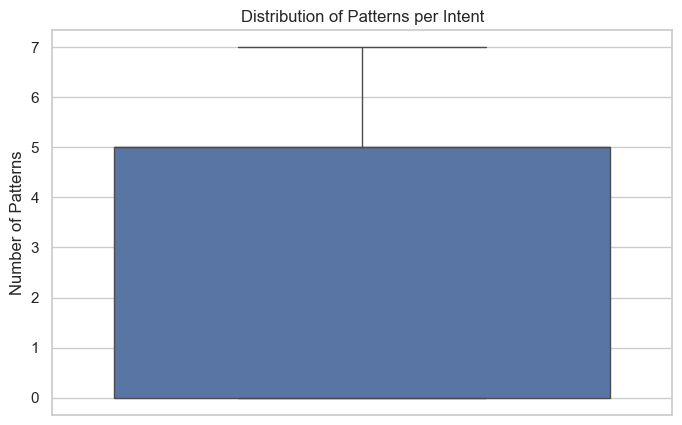

In [10]:
# Boxplot of the number of patterns per intent
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    y="num_patterns"
)

plt.title("Distribution of Patterns per Intent")
plt.ylabel("Number of Patterns")

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_16620\448716906.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


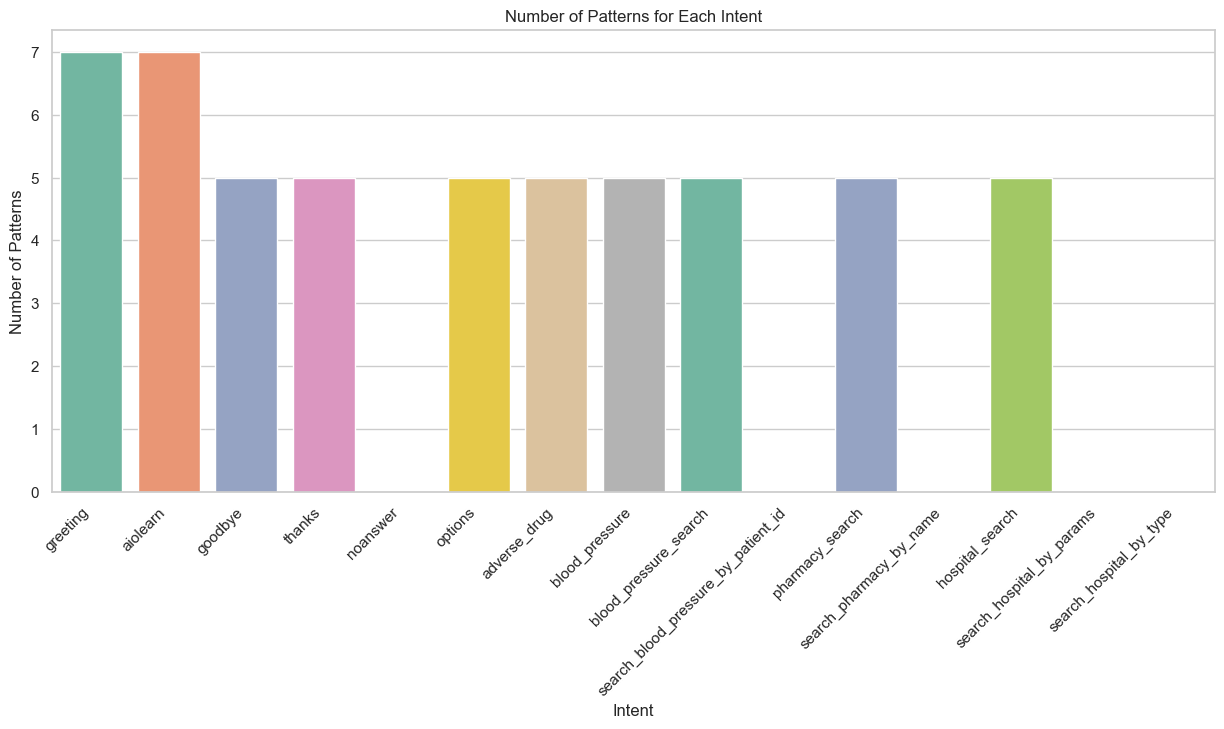

In [11]:
plt.figure(figsize=(15, 6))

sns.barplot(
    data=data,
    x="tag",
    y="num_patterns",palette='Set2'
)

plt.xticks(rotation=45, ha="right")
plt.title("Number of Patterns for Each Intent")
plt.xlabel("Intent")
plt.ylabel("Number of Patterns")

plt.show()

# Create DataFrame for pattern length analysis

In [12]:
# 
pattern_data = []

for intent in intents["intents"]:
    for pattern in intent["patterns"]:
        pattern_data.append({
            "tag": intent["tag"],
            "pattern": pattern,
            "length": len(pattern.split())
        })

pattern_df = pd.DataFrame(pattern_data)

print(pattern_df.head(25))

         tag                              pattern  length
0   greeting                             Hi there       2
1   greeting                          How are you       3
2   greeting                     Is anyone there?       3
3   greeting                                  Hey       1
4   greeting                                 Hola       1
5   greeting                                Hello       1
6   greeting                             Good day       2
7   aiolearn                    what is aiolearn?       3
8   aiolearn                             aiolearn       1
9   aiolearn                    aiolearn academy?       2
10  aiolearn                              academy       1
11  aiolearn  the best programming and ai academy       6
12  aiolearn                            aiolearn?       1
13  aiolearn                best academy in iran?       4
14   goodbye                                  Bye       1
15   goodbye                        See you later       3
16   goodbye  

In [13]:
pattern_df["length"].describe()

count    54.000000
mean      3.740741
std       2.111828
min       1.000000
25%       2.000000
50%       4.000000
75%       5.000000
max       9.000000
Name: length, dtype: float64

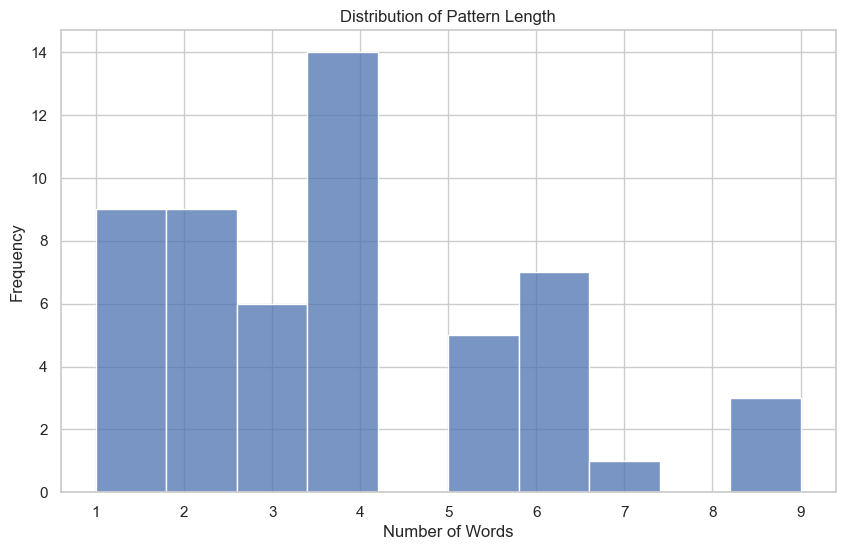

In [14]:
# Histogram of the length of patterns
plt.figure(figsize=(10, 6))

sns.histplot(
    data=pattern_df,
    x="length",
    bins=10
)

plt.title("Distribution of Pattern Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# Extract all words from patterns


In [15]:

all_words = []

for pattern in pattern_df["pattern"]:
    all_words.extend(pattern.lower().split())

print(all_words[:30])

['hi', 'there', 'how', 'are', 'you', 'is', 'anyone', 'there?', 'hey', 'hola', 'hello', 'good', 'day', 'what', 'is', 'aiolearn?', 'aiolearn', 'aiolearn', 'academy?', 'academy', 'the', 'best', 'programming', 'and', 'ai', 'academy', 'aiolearn?', 'best', 'academy', 'in']


In [16]:

# Count word frequencies

word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('blood', 10), ('pressure', 10), ('for', 8), ('you', 7), ('to', 7), ('patient', 6), ('adverse', 5), ('hospital', 5), ('how', 4), ('what', 4), ('drugs', 4), ('pharmacy', 4), ('is', 3), ('academy', 3), ('thanks', 3), ('me', 3), ('list', 3), ('data', 3), ('i', 3), ('want', 3)]


In [17]:
# Create DataFrame for word frequency analysis

word_freq_df = pd.DataFrame(word_counts.most_common(),
    columns=["word", "frequency"])

print(word_freq_df.head(20))

        word  frequency
0      blood         10
1   pressure         10
2        for          8
3        you          7
4         to          7
5    patient          6
6    adverse          5
7   hospital          5
8        how          4
9       what          4
10     drugs          4
11  pharmacy          4
12        is          3
13   academy          3
14    thanks          3
15        me          3
16      list          3
17      data          3
18         i          3
19      want          3


C:\Users\HP\AppData\Local\Temp\ipykernel_16620\2656935897.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


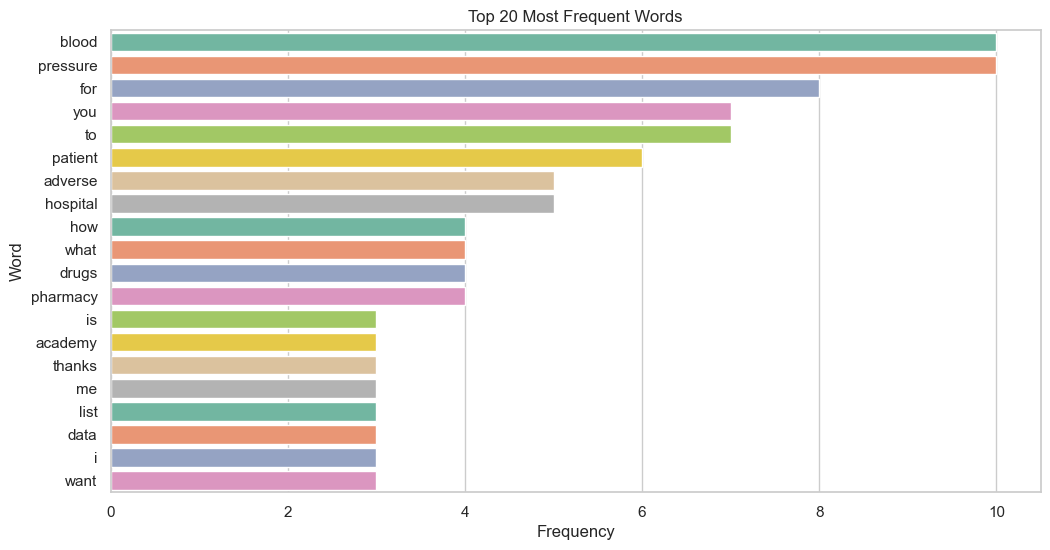

In [18]:
# Plot the 20 most frequent words

plt.figure(figsize=(12, 6))

sns.barplot(
    data=word_freq_df.head(20),palette='Set2',
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [19]:
# Check for duplicate patterns

duplicates = pattern_df[pattern_df.duplicated(subset="pattern", keep=False)]

print(duplicates)

Empty DataFrame
Columns: [tag, pattern, length]
Index: []


In [20]:
# Count duplicate patterns

print(pattern_df["pattern"].duplicated().sum())

0


In [21]:
# Show duplicated patterns and their frequencies

duplicate_counts = pattern_df["pattern"].value_counts()

print(duplicate_counts[duplicate_counts > 1])

Series([], Name: count, dtype: int64)


In [22]:
# Define common English stop words

stop_words = {
    "a", "an", "the", "is", "are", "am",
    "i", "you", "me", "my",
    "to", "for", "of", "in", "on",
    "and", "or", "but"
}

In [23]:
# Find frequent stop words

stopword_freq = word_freq_df[
    word_freq_df["word"].isin(stop_words)
]

print(stopword_freq)

   word  frequency
2   for          8
3   you          7
4    to          7
12   is          3
15   me          3
18    i          3
32    a          2
33   of          2
38  are          1
47  the          1
49  and          1
51   in          1


## EDA
## │
## ├── Intent count ✅
## ├── Pattern count ✅
# ├── describe() ✅
# ├── Pattern length ✅
# ├── Histogram / Barplot ✅
# ├── Duplicate patterns ✅
# ├── Word frequency ✅
# └── Stop Words 

# Data Cleaning / Preprocessing

In [ ]:
words = []
classes = []
documents = []

# Ignore what we want
ignore_letters = ['!','?',',','.']
# read
intents_file = open("intents.json",encoding='utf-8').read()
# Load
intents = json.loads(intents_file)
# Now create loop
for intent in intents['intents']:
   for pattern in intent['patterns']:
      # Tokenize each word
      word = nltk.word_tokenize(pattern)
      # appending word in words
      words.extend(word)
      # add documents in the corpus
      documents.append((word, intent['tag']))
      # add to our classes list
      if intent['tag'] not in classes:
         classes.append(intent['tag'])

print(documents)

[(['Hi', 'there'], 'greeting'), (['How', 'are', 'you'], 'greeting'), (['Is', 'anyone', 'there', '?'], 'greeting'), (['Hey'], 'greeting'), (['Hola'], 'greeting'), (['Hello'], 'greeting'), (['Good', 'day'], 'greeting'), (['what', 'is', 'aiolearn', '?'], 'aiolearn'), (['aiolearn'], 'aiolearn'), (['aiolearn', 'academy', '?'], 'aiolearn'), (['academy'], 'aiolearn'), (['the', 'best', 'programming', 'and', 'ai', 'academy'], 'aiolearn'), (['aiolearn', '?'], 'aiolearn'), (['best', 'academy', 'in', 'iran', '?'], 'aiolearn'), (['Bye'], 'goodbye'), (['See', 'you', 'later'], 'goodbye'), (['Goodbye'], 'goodbye'), (['Nice', 'chatting', 'to', 'you', ',', 'bye'], 'goodbye'), (['Till', 'next', 'time'], 'goodbye'), (['Thanks'], 'thanks'), (['Thank', 'you'], 'thanks'), (['That', "'s", 'helpful'], 'thanks'), (['Awesome', ',', 'thanks'], 'thanks'), (['Thanks', 'for', 'helping', 'me'], 'thanks'), (['How', 'you', 'could', 'help', 'me', '?'], 'options'), (['What', 'you', 'can', 'do', '?'], 'options'), (['What'

In [25]:

words = [lemmatizer.lemmatize(w.lower()) for w in words if w not in ignore_letters]
# Sorting words
words = sorted(list(set(words)))
# Sorting classes
classes = sorted(list(set(classes)))
# Documents = Combination between patterns and intents
print (len(documents), "documents")
# classes = intents
print (len(classes), "classes", classes)
# Words = all words, vocabulary 
print (len(words), "unique lemmatized words",words)

54 documents
10 classes ['adverse_drug', 'aiolearn', 'blood_pressure', 'blood_pressure_search', 'goodbye', 'greeting', 'hospital_search', 'options', 'pharmacy_search', 'thanks']
96 unique lemmatized words ["'s", 'a', 'academy', 'adverse', 'ai', 'aiolearn', 'all', 'and', 'anyone', 'are', 'awesome', 'be', 'behavior', 'best', 'blood', 'by', 'bye', 'can', 'causing', 'chatting', 'check', 'could', 'data', 'day', 'detail', 'do', 'dont', 'drug', 'entry', 'find', 'for', 'give', 'good', 'goodbye', 'have', 'hello', 'help', 'helpful', 'helping', 'hey', 'hi', 'history', 'hola', 'hospital', 'how', 'i', 'id', 'in', 'iran', 'is', 'later', 'list', 'load', 'locate', 'log', 'looking', 'lookup', 'management', 'me', 'module', 'nearby', 'next', 'nice', 'of', 'offered', 'open', 'patient', 'pharmacy', 'pressure', 'programming', 'provide', 'reaction', 'related', 'result', 'search', 'searching', 'see', 'show', 'suitable', 'support', 'task', 'thank', 'thanks', 'that', 'the', 'there', 'till', 'time', 'to', 'trans

In [26]:
# For saving preprocessing data
pickle.dump(words,open('words.pkl','wb'))
pickle.dump(classes,open('classes.pkl','wb'))


In [27]:
# Creating our training data
training = []
# 0 *10 classes as we have 10 classes
output_empty = [0] * len(classes)
# 
for doc in documents:
    bag = []
    pattern_words = doc[0]
    pattern_words = [lemmatizer.lemmatize(word.lower()) for word in pattern_words]
    for word in words:
        bag.append(1) if word in pattern_words else bag.append(0)
    output_row = list(output_empty)
    output_row[classes.index(doc[1])] = 1
    
    training.append([bag, output_row])

# Combining and shuffling the training data
random.shuffle(training)
training = np.array(training, dtype=object)

# Splitting the training data into patterns and classes
train_x = list(training[:,0])
train_y = list(training[:,1])
print("Training data created")

Training data created


In [28]:

# Split data into training and testing sets

x_train, X_test, y_train, y_test = train_test_split(
    np.array(train_x),
    np.array(train_y),
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(np.array(train_y), axis=1)
)

## 🧠 Model Architecture




In [29]:
# Create model
model = Sequential()
model.add(Dense(128, input_shape=(len(train_x[0]),), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(train_y[0]), activation='softmax'))
model.summary()

# compile model
sgd = SGD(learning_rate=0.01, decay=1e-6, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])



C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,322 (83.29 KB)

 Trainable params: 21,322 (83.29 KB)

 Non-trainable params: 0 (0.00 B)

C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [30]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [31]:
history = model.fit(np.array(x_train), np.array(y_train),epochs=100,
    batch_size=5,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.0588 - loss: 2.3313 - val_accuracy: 0.1111 - val_loss: 2.3249
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1471 - loss: 2.2398 - val_accuracy: 0.2222 - val_loss: 2.3114
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1765 - loss: 2.2506 - val_accuracy: 0.2222 - val_loss: 2.3061
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2059 - loss: 2.1462 - val_accuracy: 0.2222 - val_loss: 2.2993
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 2.0245 - val_accuracy: 0.1111 - val_loss: 2.3004
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3529 - loss: 1.9634 - val_accuracy: 0.1111 - val_loss: 2.2810
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3824 - loss: 1.9576 - val_accuracy: 0.1111 - val_loss: 2.2443
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5294 - loss: 1.8200 - val_accuracy: 0.1111 - val_loss:

In [32]:
# Save the model
model.save("chatbot_model.h5")

In [33]:
# load model
model.load_weights('chatbot_model.h5')

# Evaluation

In [34]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [35]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.8865458965301514
Test Accuracy: 0.6363636255264282


In [36]:
# Predict test data

test_predictions = model.predict(X_test,verbose=0)

predicted_classes = np.argmax(test_predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

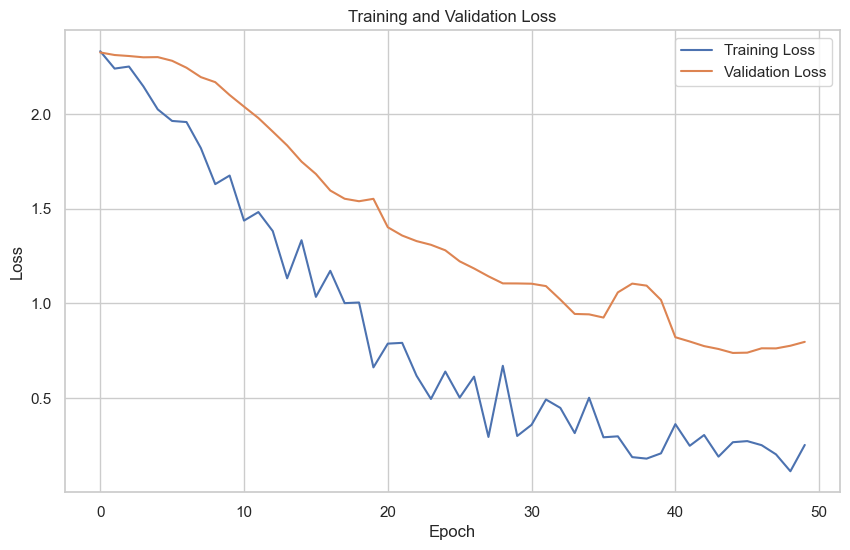

In [37]:
# Plot training and validation loss

plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

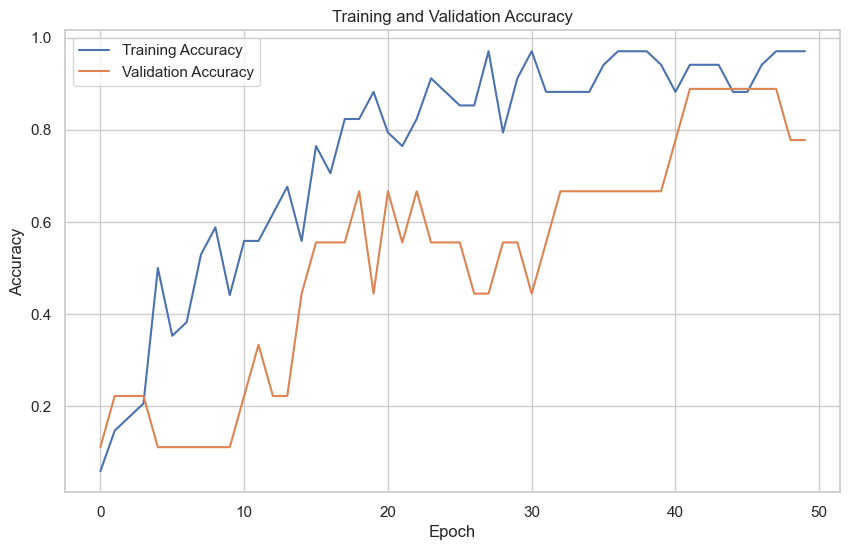

In [38]:
# Plot training and validation accuracy

plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [39]:
# Get the best training accuracy and validation accuracy

best_accuracy = max(history.history["accuracy"])
best_val_accuracy = max(history.history["val_accuracy"])

print("Best Training Accuracy:", best_accuracy)
print("Best Validation Accuracy:", best_val_accuracy)

Best Training Accuracy: 0.970588207244873
Best Validation Accuracy: 0.8888888955116272


In [40]:
# Get the minimum training loss and validation loss

best_loss = min(history.history["loss"])
best_val_loss = min(history.history["val_loss"])

print("Minimum Training Loss:", best_loss)
print("Minimum Validation Loss:", best_val_loss)

Minimum Training Loss: 0.1144595742225647
Minimum Validation Loss: 0.7388821840286255


In [41]:
# Get the epoch with the best validation accuracy

best_epoch = history.history["val_accuracy"].index(best_val_accuracy) + 1

print("Best Validation Epoch:", best_epoch)

Best Validation Epoch: 42


In [42]:
# Calculate training accuracy

accuracy = accuracy_score(true_classes, predicted_classes)

print("Training Accuracy:", accuracy)

Training Accuracy: 0.6363636363636364


In [43]:
# Confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

[[0 0 0 0 0 0 0 0 1 0]
 [0 2 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0]]


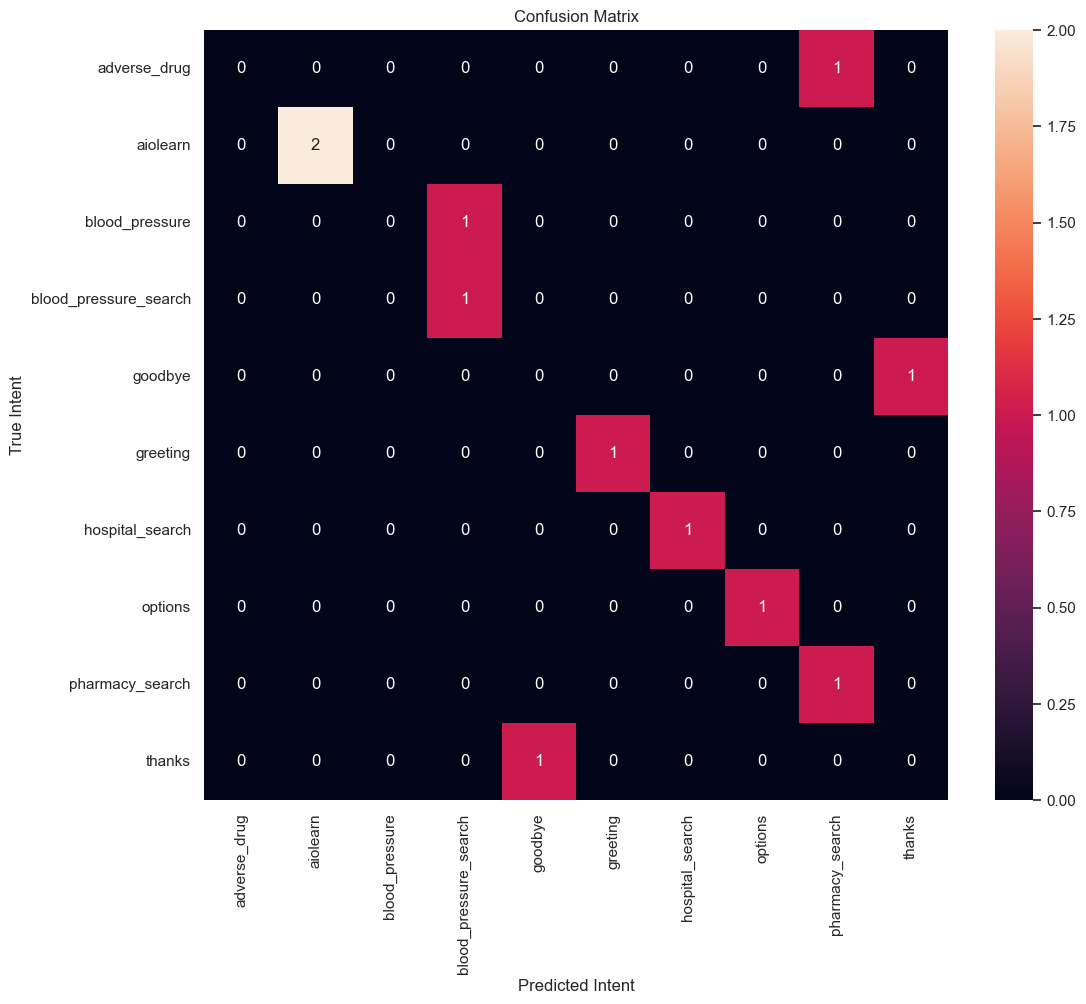

In [44]:
# Plot confusion matrix

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")

plt.show()

In [45]:
# Find misclassified patterns

for i in range(len(true_classes)):
    if true_classes[i] != predicted_classes[i]:
        print("Pattern:", pattern_df.iloc[i]["pattern"])
        print("True:", classes[true_classes[i]])
        print("Predicted:", classes[predicted_classes[i]])
        print("-" * 50)

Pattern: How are you
True: goodbye
Predicted: thanks
--------------------------------------------------
Pattern: Hola
True: blood_pressure
Predicted: blood_pressure_search
--------------------------------------------------
Pattern: aiolearn
True: thanks
Predicted: goodbye
--------------------------------------------------
Pattern: aiolearn academy?
True: adverse_drug
Predicted: pharmacy_search
--------------------------------------------------


In [46]:
# Generate classification report on test data

from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=classes
)

print(report)

                       precision    recall  f1-score   support

         adverse_drug       0.00      0.00      0.00         1
             aiolearn       1.00      1.00      1.00         2
       blood_pressure       0.00      0.00      0.00         1
blood_pressure_search       0.50      1.00      0.67         1
              goodbye       0.00      0.00      0.00         1
             greeting       1.00      1.00      1.00         1
      hospital_search       1.00      1.00      1.00         1
              options       1.00      1.00      1.00         1
      pharmacy_search       0.50      1.00      0.67         1
               thanks       0.00      0.00      0.00         1

             accuracy                           0.64        11
            macro avg       0.50      0.60      0.53        11
         weighted avg       0.55      0.64      0.58        11



C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [52]:
print("x_train:", x_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (43, 96)
X_test: (11, 96)
y_train: (43, 10)
y_test: (11, 10)


Hello
 ↓
Tokenize
 ↓
Lemmatize
 ↓
Bag of Words
 ↓
Model.predict()
 ↓
greeting
 ↓
انتخاب یک response

In [47]:

def clean_up_sentence(sentence):
    # tokenize the pattern - splitting words into array
    sentence_words = nltk.word_tokenize(sentence)
    # stemming every word - reducing to base form
    sentence_words = [lemmatizer.lemmatize(word.lower()) for word in sentence_words]
    return sentence_words


# return bag of words array: 0 or 1 for words that exist in sentence
def bag_of_words(sentence, words, show_details=True):
    # tokenizing patterns
    sentence_words = clean_up_sentence(sentence)
    # bag of words - vocabulary matrix
    bag = [0]*len(words)  
    for s in sentence_words:
        for i,word in enumerate(words):
            if word == s: 
                # assign 1 if current word is in the vocabulary position
                bag[i] = 1
                if show_details:
                    print ("found in bag: %s" % word)
    return(np.array(bag))

def predict_class(sentence):
    # filter below  threshold predictions
    p = bag_of_words(sentence, words,show_details=True)
    res = model.predict(np.array([p]))[0]
    ERROR_THRESHOLD = 0.25
    print(res)
    results = [[i,r] for i,r in enumerate(res) if r>ERROR_THRESHOLD]
    # sorting strength probability
    results.sort(key=lambda x: x[1], reverse=True)

    return_list = []
    
    for r in results:
        return_list.append({"intent": classes[r[0]], "probability": str(r[1])})
    return return_list

def getResponse(ints, intents_json):
    tag = ints[0]['intent']
    list_of_intents = intents_json['intents']
    for i in list_of_intents:
        if(i['tag']== tag):
            result = random.choice(i['responses'])
            break
    return result


In [48]:

def send():
    msg = EntryBox.get("1.0",'end-1c').strip()
    EntryBox.delete("0.0",END)

    if msg != '':
        ChatBox.config(state=NORMAL)
        ChatBox.insert(END, "You: " + msg + '\n\n')
        ChatBox.config(foreground="#446665", font=("Verdana", 12 ))
    
        ints = predict_class(msg)
        print(ints)
        res = getResponse(ints, intents)
        
        ChatBox.insert(END, "Bot: " + res + '\n\n')
            
        ChatBox.config(state=DISABLED)
        ChatBox.yview(END)
 

root = Tk()
root.title("Aiolearn Chatbot")
root.geometry("400x500")
root.resizable(width=TRUE, height=TRUE)

#Create Chat window
ChatBox = Text(root, bd=0, bg="white", height="8", width="50", font="Arial",)

ChatBox.config(state=DISABLED)

#Bind scrollbar to Chat window
scrollbar = Scrollbar(root, command=ChatBox.yview, cursor="heart")
ChatBox['yscrollcommand'] = scrollbar.set

#Create Button to send message
SendButton = Button(root, font=("Verdana",12,'bold'), text="ارسال", width="12", height=5,
                    bd=0, bg="#f9a602", activebackground="#3c9d9b",fg='#000000',
                    command= send )

#Create the box to enter message
EntryBox = Text(root, bd=0, bg="white",width="29", height="5", font="Arial")
#EntryBox.bind("<Return>", send)


#Place all components on the screen
scrollbar.place(x=376,y=6, height=386)
ChatBox.place(x=6,y=6, height=386, width=370)
EntryBox.place(x=128, y=401, height=90, width=265)
SendButton.place(x=6, y=401, height=90)

root.mainloop()


found in bag: hello
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[0.00598021 0.00878215 0.00254223 0.00165086 0.02292907 0.91474366
 0.00473837 0.01362389 0.0081505  0.01685917]
[{'intent': 'greeting', 'probability': '0.91474366'}]
found in bag: how
found in bag: are
found in bag: you
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[1.0976109e-03 1.5570270e-03 2.2854352e-04 1.8801539e-04 2.3503380e-03
 9.7133684e-01 7.6157995e-04 1.3833590e-02 6.1771699e-04 8.0285678e-03]
[{'intent': 'greeting', 'probability': '0.97133684'}]


In [7]:
git --version

NameError: name 'git' is not defined